# Implementing Monte Carlo Methods for Estimating Value Functions

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Monte Carlo methods for value estimation
- Implement first-visit and every-visit Monte Carlo
- Estimate state value functions using Monte Carlo
- Compare Monte Carlo with other methods
- Apply Monte Carlo to RL environments

## 🔗 Prerequisites

- ✅ Understanding of value functions (V(s), Q(s,a))
- ✅ Understanding of episodes and returns
- ✅ Python knowledge (functions, dictionaries, loops)
- ✅ NumPy, Matplotlib knowledge
- ✅ Basic RL concepts (states, actions, rewards, policies)

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 2**:
- Implementing Monte Carlo methods for estimating value functions

---

## Introduction

**Monte Carlo methods** learn value functions from experience (sample episodes). They don't require a model of the environment and use actual returns (sum of rewards) observed from episodes.

## Lesson Brief

This lesson explains how **Monte Carlo methods** estimate values from complete episodes.

Students will see how learning can happen from returns observed after an episode finishes, without needing a model of the environment.

Why this matters: Monte Carlo methods are an important stepping stone between dynamic programming and temporal-difference learning.

They also help students think carefully about what a return actually means.

## What this notebook should teach

This notebook is about learning from **complete episodes**.

By the end, you should be able to:

- compute returns from an episode
- explain first-visit vs every-visit Monte Carlo
- estimate state values from sampled episodes


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

print("✅ Libraries imported!")
print("\nImplementing Monte Carlo Methods for Value Estimation")
print("=" * 60)

✅ Libraries imported!

Implementing Monte Carlo Methods for Value Estimation


## Part 1: Understanding Monte Carlo Methods


In [2]:
print("=" * 60)
print("Part 1: Understanding Monte Carlo Methods")
print("=" * 60)

example_episode = [
    ("A", 0),
    ("B", 0),
    ("C", 1),
]
gamma = 0.9

returns = []
G = 0.0
for state, reward in reversed(example_episode):
    G = reward + gamma * G
    returns.insert(0, (state, G))

print("Example episode:", example_episode)
print("Discount factor:", gamma)
print("Returns from each state:")
for state, g in returns:
    print(f"  State {state}: return = {g:.3f}")

Part 1: Understanding Monte Carlo Methods
Example episode: [('A', 0), ('B', 0), ('C', 1)]
Discount factor: 0.9
Returns from each state:
  State A: return = 0.810
  State B: return = 0.900
  State C: return = 1.000


## Part 2: First-Visit Monte Carlo Implementation


In [3]:
print("\n" + "=" * 60)
print("Part 2: First-Visit Monte Carlo Implementation")
print("=" * 60)

episodes = [
    [("A", 0), ("B", 0), ("C", 1)],
    [("A", 0), ("A", 0), ("C", 1)],
    [("B", 0), ("C", 1)],
]


def first_visit_mc(episodes, gamma=0.9):
    returns_by_state = defaultdict(list)
    for episode in episodes:
        visited = set()
        G = 0.0
        returns = []
        for state, reward in reversed(episode):
            G = reward + gamma * G
            returns.insert(0, (state, G))
        for state, G in returns:
            if state not in visited:
                returns_by_state[state].append(G)
                visited.add(state)
    return {state: np.mean(values) for state, values in returns_by_state.items()}


fv_values = first_visit_mc(episodes)
print("First-visit MC estimates:", {k: round(v, 3) for k, v in fv_values.items()})


Part 2: First-Visit Monte Carlo Implementation
First-visit MC estimates: {'A': np.float64(0.81), 'B': np.float64(0.9), 'C': np.float64(1.0)}


## Part 3: Every-Visit Monte Carlo Implementation


In [4]:
print("\n" + "=" * 60)
print("Part 3: Every-Visit Monte Carlo Implementation")
print("=" * 60)


def every_visit_mc(episodes, gamma=0.9):
    returns_by_state = defaultdict(list)
    for episode in episodes:
        G = 0.0
        returns = []
        for state, reward in reversed(episode):
            G = reward + gamma * G
            returns.insert(0, (state, G))
        for state, G in returns:
            returns_by_state[state].append(G)
    return {state: np.mean(values) for state, values in returns_by_state.items()}


ev_values = every_visit_mc(episodes)
print("Every-visit MC estimates:", {k: round(v, 3) for k, v in ev_values.items()})
print("\nCheckpoint:")
print("If a state appears multiple times in one episode, every-visit MC uses all of them,")
print("while first-visit MC only uses the first occurrence.")


Part 3: Every-Visit Monte Carlo Implementation
Every-visit MC estimates: {'A': np.float64(0.84), 'B': np.float64(0.9), 'C': np.float64(1.0)}

Checkpoint:
If a state appears multiple times in one episode, every-visit MC uses all of them,
while first-visit MC only uses the first occurrence.


## Monte Carlo in context

Monte Carlo methods are especially natural when:

- the task is episodic
- you can wait until the episode ends
- you want to estimate values directly from sampled returns

They become less convenient when you need online updates before the episode finishes.

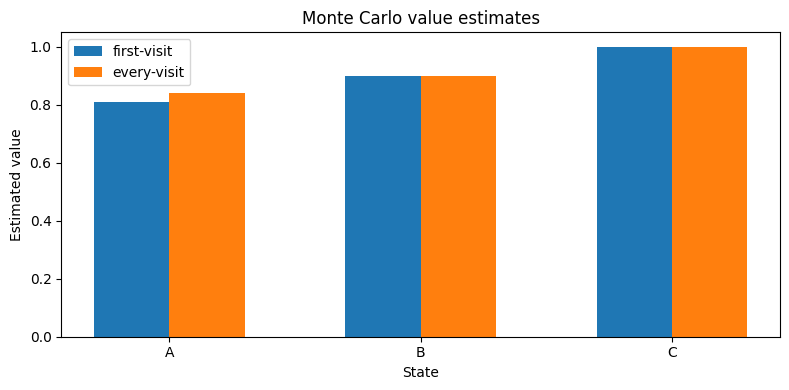

In [5]:
states = sorted(set(list(fv_values.keys()) + list(ev_values.keys())))
first_vals = [fv_values.get(state, np.nan) for state in states]
every_vals = [ev_values.get(state, np.nan) for state in states]

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(states)) - 0.15, first_vals, width=0.3, label="first-visit")
plt.bar(np.arange(len(states)) + 0.15, every_vals, width=0.3, label="every-visit")
plt.xticks(np.arange(len(states)), states)
plt.xlabel("State")
plt.ylabel("Estimated value")
plt.title("Monte Carlo value estimates")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

Monte Carlo methods estimate value from **complete sampled returns**.

### Main takeaways

- First-visit MC uses the first occurrence of a state in each episode.
- Every-visit MC uses all occurrences.
- Both methods are model-free.
- Both usually have higher variance than TD methods.

### Why this matters

Monte Carlo gives you a clean way to think about learning from complete experience
before moving to TD learning, which updates earlier and more often.

## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

## Closing Takeaway

**Teaching takeaway:** Monte Carlo methods estimate value from complete episodes, which makes the logic intuitive but can increase variance.

**If students remember one idea:** Monte Carlo waits until the end of the episode, then uses the observed return as the learning signal.

**Quick check before moving on:**
- Can you explain why Monte Carlo needs complete returns before updating?
- Can you describe one advantage and one limitation of waiting until episode end?

**Bridge to the next step:** This leads naturally to temporal-difference learning, which updates earlier and more often.
